In [3]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import os
import sys
import urllib.request
import time
import json

from dotenv import load_dotenv
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
import re


import matplotlib.pyplot as plt
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

In [4]:
import os
from dotenv import load_dotenv

# .env 파일의 환경 변수를 로드합니다.
load_dotenv()

# os.getenv()를 사용하여 값을 가져옵니다.
client_id = os.getenv("Client_ID")
client_secret = os.getenv("Client_Secret")

In [6]:
# [CODE 1] : 네이버 API에 요청 보내는 함수
def getRequestUrl(url):    
    req = urllib.request.Request(url)
    req.add_header("X-Naver-Client-Id", client_id)  # 네이버 API 인증을 위한 Client ID / Secret 헤더 추가 (두 변수의 값은 네이버API 값)
    req.add_header("X-Naver-Client-Secret", client_secret)
    
    try: 
        response = urllib.request.urlopen(req)  ## 요청을 전송하고, 서버에서 받은 응답을 저장
        if response.getcode() == 200:   ## 정상 응답일 
            print ("[%s] Url Request Success" % datetime.datetime.now()) # 현재 시각과 성공 메시지 출력
            return response.read().decode('utf-8')  ## 응답 데이터를 utf-8로 디코딩한 후 문자열로 리턴 
    except Exception as e:   # 예외 처리 (발생한 오류를 변수 e에)
        print(e)
        print("[%s] Error for URL : %s" % (datetime.datetime.now(), url))
        return None


# [CODE 2]  :  네이버 Open API를 호출하고 JSON으로 변환
# node(검색 대상,'news','blog','cafe' 등), srcText(검색어), start(검색 시작 위치), display → 한 번에 가져올 결과 수 (최대 100)

def getNaverSearch(node, srcText, start, display): 
    base = "https://openapi.naver.com/v1/search"   # https://openapi.naver.com/v1/search/{node}.json?query={검색어}&start={시작}&display={갯수}
    node = "/%s.json" % node
    parameters = "?query=%s&start=%s&display=%s" % (urllib.parse.quote(srcText), start, display) # urllib.parse.quote(srcText) : 검색어를 URL 안전하게 인코딩
    
    url = base + node + parameters    
    responseDecode = getRequestUrl(url)   # [CODE 1]
    
    if (responseDecode == None):
        return None
    else:
        return json.loads(responseDecode)


# [CODE 3]
def getPostData(post, jsonResult, cnt):    
    title = post['title']
    description = post['description']
    org_link = post['originallink']
    link = post['link']
    
    pDate = datetime.datetime.strptime(post['pubDate'],  '%a, %d %b %Y %H:%M:%S +0900')
    pDate = pDate.strftime('%Y-%m-%d %H:%M:%S')
    
    jsonResult.append({'cnt':cnt, 'title':title, 'description': description, 
'org_link':org_link,   'link': org_link,   'pDate':pDate})

    
##-------------------
node = 'news'   # 크롤링 대상 노드 : 네이버 '뉴스', 블로그를 대상으로 하려면 'blog'
srcText = input('검색어를 입력하세요: ')
cnt = 0
jsonResult = []

jsonResponse = getNaverSearch(node, srcText, 1, 100)  # [CODE 2]로 
    
total = jsonResponse['total']
 
while ((jsonResponse != None) and (jsonResponse['display'] != 0)):         
    for post in jsonResponse['items']:
        cnt += 1
        getPostData(post, jsonResult, cnt)  # [CODE 3]으로       
        
    start = jsonResponse['start'] + jsonResponse['display']
    if start == 1001: break    # 네이버 뉴스는 1000개까지만 무료 제공됨
    jsonResponse = getNaverSearch(node, srcText, start, 100)  #[CODE 2]       

print('전체 검색 : %d 건' %total)
    
with open('../../data/%s_naver_%s.json' % (srcText, node), 'w', encoding='utf8') as outfile:
    jsonFile = json.dumps(jsonResult,  indent = 4, sort_keys = True,  ensure_ascii = False)
                        
    outfile.write(jsonFile)
        
print("가져온 데이터 : %d 건" %(cnt))
print ('%s_naver_%s.json SAVED' % (srcText, node))

[2026-01-12 21:13:49.003877] Url Request Success
[2026-01-12 21:13:49.335976] Url Request Success
[2026-01-12 21:13:49.547021] Url Request Success
[2026-01-12 21:13:49.746766] Url Request Success
[2026-01-12 21:13:49.960688] Url Request Success
[2026-01-12 21:13:50.199257] Url Request Success
[2026-01-12 21:13:50.432160] Url Request Success
[2026-01-12 21:13:50.729365] Url Request Success
[2026-01-12 21:13:50.924290] Url Request Success
[2026-01-12 21:13:51.113595] Url Request Success
전체 검색 : 7427 건
가져온 데이터 : 1000 건
검정고무신_naver_news.json SAVED


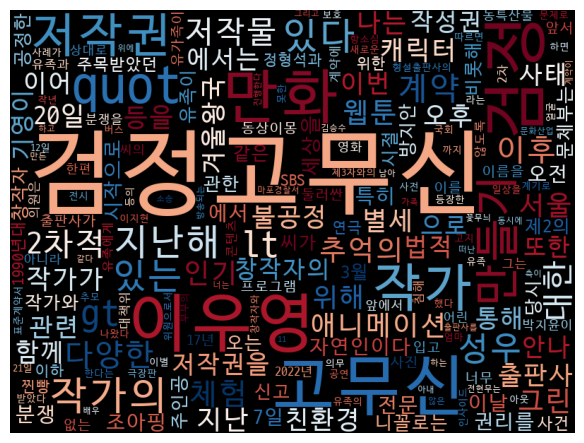

In [8]:
filename = f"../../data/{srcText}_naver_{node}.json"
data = json.loads(open(filename, 'r' , encoding = 'utf-8').read())

descriptions = []

for item in data:
    desc = item.get('description')
    if isinstance(desc, str):
        # 1. HTML 태그 제거
        desc = re.sub(r'<[^>]+>', ' ', desc)
        # 2. 한글, 영어, 공백만 남기기
        desc = re.sub(r'[^가-힣0-9a-zA-Z\s]', ' ', desc)
        # 3. 공백 정리
        desc = re.sub(r'\s+', ' ', desc).strip()

        descriptions.append(desc)

words = [word for d in descriptions for word in d.split()]
words2 = [i   for i in words  if (len(i) >=2) & (len(i)<=6)  ]

cnt = Counter(words2)

wc = WordCloud(
    font_path='/home/erion/.local/share/fonts/d2codingligature-nerd-font/D2CodingLigatureNerdFont-Regular.ttf',  # 폰트 경로 필수!
    background_color='black',
    width=800,
    height=600,
    colormap='RdBu'
)

cloud = wc.generate_from_frequencies(cnt)

plt.imshow(cloud)
plt.axis('off')
plt.show()